<a href="https://colab.research.google.com/github/DataScientist64/DataAnalysis/blob/main/coughclassification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!git clone https://github.com/bagustris/detect-segment-cough

Cloning into 'detect-segment-cough'...
remote: Enumerating objects: 122, done.
remote: Counting objects: 100% (39/39), done.
remote: Compressing objects: 100% (8/8), done.
remote: Total 122 (delta 33), reused 31 (delta 31), pack-reused 83 (from 1)
Receiving objects: 100% (122/122), 826.21 KiB | 8.61 MiB/s, done.
Resolving deltas: 100% (51/51), done.


In [2]:
import sys
sys.path.append('/content/detect-segment-cough/src')


In [3]:
import os
os.listdir('/content/detect-segment-cough/src')


['DSP.py',
 'convert_files.py',
 'segmentation.py',
 'feature_class.py',
 '__init__.py']

In [6]:
!ls detect-segment-cough/src/

convert_files.py  DSP.py  feature_class.py  __init__.py  segmentation.py


In [7]:
import sys
sys.path.append('/content/detect-segment-cough/src')


In [14]:
from segmentation import segment_cough
import scipy.io.wavfile as wavfile

audio_path = "/content/detect-segment-cough/sample_recordings/cough.wav"
fs, audio_data = wavfile.read(audio_path)
segments = segment_cough(audio_data, fs=fs)

segments

([array([0, 0, 0, ..., 0, 0, 0], dtype=int16),
  array([-2318, -2440, -2549, ...,     0,     0,     0], dtype=int16)],
 array([ True,  True,  True, ..., False, False, False]))

In [16]:
import numpy as np
from scipy.signal import butter, filtfilt, hilbert, resample
from scipy.io import wavfile

def butter_bandpass(lowcut, highcut, fs, order=4):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    return b, a

def bandpass_filter(data, lowcut, highcut, fs, order=4):
    b, a = butter_bandpass(lowcut, highcut, fs, order=order)
    y = filtfilt(b, a, data)
    return y

def envelope(signal):
    analytic = hilbert(signal)
    return np.abs(analytic)

def load_audio(path):
    fs, data = wavfile.read(path)
    if data.ndim > 1:
        data = data[:, 0]  # take mono
    data = data.astype(np.float32)
    return fs, data


In [21]:
import numpy as np
import scipy.signal as signal
from scipy.stats import kurtosis
from python_speech_features import mfcc

def safe_spectral_centroid(data, fs):
    f, t, Sxx = signal.spectrogram(data, fs)
    eps = 1e-10
    centroid = np.sum(f[:, None] * Sxx, axis=0) / (np.sum(Sxx, axis=0) + eps)
    return np.nanmean(centroid)

class FeatureExtractor:
    def __init__(self, n_mfcc=13):
        self.n_mfcc = n_mfcc

    def extract(self, audio_path):
        fs, data = load_audio(audio_path)
        data = data / (np.max(np.abs(data)) + 1e-10)

        # MFCCs
        mfcc_feat = mfcc(data, samplerate=fs, numcep=self.n_mfcc, nfft=2048)

        # RMS
        rms = np.sqrt(np.mean(data**2))

        # ZCR
        zcr = ((data[:-1] * data[1:]) < 0).sum() / len(data)

        # Spectral centroid (fixed)
        centroid = safe_spectral_centroid(data, fs)

        # Kurtosis
        kurt = kurtosis(data)

        return {
            "mfcc": mfcc_feat,
            "rms": rms,
            "zcr": zcr,
            "centroid": centroid,
            "kurtosis": kurt
        }

In [24]:
def segment_cough(audio_path, min_len=0.1):
    fs, data = load_audio(audio_path)
    env = envelope(data)
    env = env / (np.max(env) + 1e-10)

    # Adaptive threshold
    thr = np.mean(env) + 1.5 * np.std(env)

    mask = env > thr

    segments = []
    start = None

    for i, val in enumerate(mask):
        if val and start is None:
            start = i
        elif not val and start is not None:
            end = i
            duration = (end - start) / fs
            if duration >= min_len:
                segments.append((start / fs, end / fs))
            start = None

    return segments, thr


In [25]:
audio_path = "/content/detect-segment-cough/sample_recordings/cough.wav"

# Segmentation
segments = segment_cough(audio_path)
print("Segments:", segments)

# Features
fe = FeatureExtractor()
features = fe.extract(audio_path)
features

Segments: ([], np.float32(0.2748961))


{'mfcc': array([[-3.60436534e+01,  0.00000000e+00,  0.00000000e+00, ...,
          9.64028692e-15,  0.00000000e+00,  0.00000000e+00],
        [-3.60436534e+01,  0.00000000e+00,  0.00000000e+00, ...,
          9.64028692e-15,  0.00000000e+00,  0.00000000e+00],
        [-3.60436534e+01,  0.00000000e+00,  0.00000000e+00, ...,
          9.64028692e-15,  0.00000000e+00,  0.00000000e+00],
        ...,
        [-1.44697126e+01, -7.86134873e+00,  2.21354442e+01, ...,
         -3.43661207e+00,  1.14014949e+01,  1.75592058e+01],
        [-1.49634600e+01, -1.23677041e+01,  1.51862986e+01, ...,
         -6.87072199e-01,  1.13009589e+01,  1.82980279e+01],
        [-1.57007499e+01, -1.57057304e+01,  1.21928368e+01, ...,
          6.77902713e+00,  1.08068255e+01,  1.01111886e+01]]),
 'rms': np.float32(0.12482842),
 'zcr': np.float64(0.03587147887323944),
 'centroid': np.float64(772.4215023968497),
 'kurtosis': np.float32(14.18116)}

In [26]:
fe = FeatureExtractor()

def extract_features_from_file(path):
    f = fe.extract(path)
    # Flatten MFCCs into a single vector
    mfcc_mean = np.mean(f["mfcc"], axis=0)
    mfcc_std = np.std(f["mfcc"], axis=0)

    return np.concatenate([
        mfcc_mean,
        mfcc_std,
        [f["rms"], f["zcr"], f["centroid"], f["kurtosis"]]
    ])


In [29]:
!mkdir -p /content/data/cough
!mkdir -p /content/data/non_cough

In [30]:
!cp /content/detect-segment-cough/sample_recordings/cough.wav /content/data/cough/

In [31]:
import numpy as np
from scipy.io.wavfile import write

fs = 16000
noise = np.random.randn(fs * 2).astype(np.float32)
write("/content/data/non_cough/noise.wav", fs, noise)


In [32]:
import os
import numpy as np

X = []
y = []

base = "/content/data"

for label, folder in enumerate(["cough", "non_cough"]):
    folder_path = os.path.join(base, folder)
    for fname in os.listdir(folder_path):
        if fname.endswith(".wav"):
            path = os.path.join(folder_path, fname)
            feat = extract_features_from_file(path)
            X.append(feat)
            y.append(label)

X = np.array(X)
y = np.array(y)

print("Dataset shape:", X.shape, "Labels:", y.shape)

Dataset shape: (2, 30) Labels: (2,)


In [35]:
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# With only 2 samples, train_test_split can lead to a training set
# with only one class. For now, we will train on the full dataset
# to allow the model to fit.
X_train = X
y_train = y

clf = SVC(kernel="rbf", probability=True)
clf.fit(X_train, y_train)

# With no separate test set, classification report is not applicable here.
# For proper evaluation, please add more data to create a meaningful test set.

SVC(probability=True)

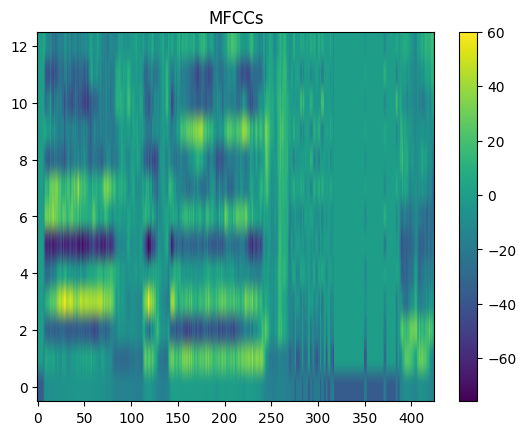

In [36]:
import matplotlib.pyplot as plt

plt.imshow(features["mfcc"].T, aspect='auto', origin='lower')
plt.title("MFCCs")
plt.colorbar()
plt.show()


In [37]:
test_file = "/content/detect-segment-cough/sample_recordings/cough.wav"
feat = extract_features_from_file(test_file)
pred = clf.predict([feat])[0]
prob = clf.predict_proba([feat])[0]

print("Prediction:", "cough" if pred == 0 else "non_cough")
print("Confidence:", prob[pred])


Prediction: cough
Confidence: 0.37502455419406866


In [38]:
!cp /content/detect-segment-cough/sample_recordings/*.wav /content/data/cough/

In [39]:
for i in range(5):
    noise = np.random.randn(16000 * 2).astype(np.float32)
    write(f"/content/data/non_cough/noise_{i}.wav", 16000, noise)


In [42]:
from sklearn.ensemble import RandomForestClassifier

clf = RandomForestClassifier(n_estimators=300)
clf.fit(X_train, y_train)


RandomForestClassifier(n_estimators=300)

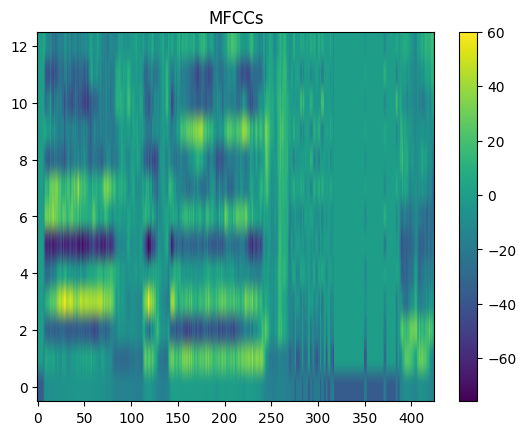

In [43]:
plt.imshow(features["mfcc"].T, aspect='auto', origin='lower')
plt.title("MFCCs")
plt.colorbar()
plt.show()


In [44]:
test_file = "/content/detect-segment-cough/sample_recordings/cough.wav"
feat = extract_features_from_file(test_file)
pred = clf.predict([feat])[0]
prob = clf.predict_proba([feat])[0]

print("Prediction:", "cough" if pred == 0 else "non_cough")
print("Confidence:", prob[pred])

Prediction: cough
Confidence: 0.7066666666666667
